# EDA

Exploratory plots of the cleaned corpus:

1. Reviews over time
2. Review count per author
3. Review count per designer
4. Data thresholds for designer and author

In [23]:
# load the cleaned data
df = pd.read_csv('data/stylecom_cleaned.csv')
df['year'] = pd.to_datetime(df['date'], format='%d-%b-%y').dt.year

print('rows:', len(df))
df.head()

rows: 6501


,year,season,designer,author,city,date,review
0,1999,Spring,Matt Nye,Armand Limnander,New York,17-Sep-99,Designer Matt Nye's sophomore show featured a ...
1,1999,Spring,Giorgio Armani,Armand Limnander,Milan,29-Sep-99,"Armani proposed a light, feminine silhouette f..."
2,1999,Spring,Eric Bergère,Armand Limnander,Paris,4-Oct-99,Broadway Garnier was the theme for Eric Berg'r...
3,1999,Spring,Céline,Armand Limnander,Paris,7-Oct-99,Getaway glamour was the theme for Celine's str...
4,1999,Spring,Byblos,Armand Limnander,Milan,27-Sep-99,Judo Jetson blends my favorite cartoon charact...


## 1. Reviews over time

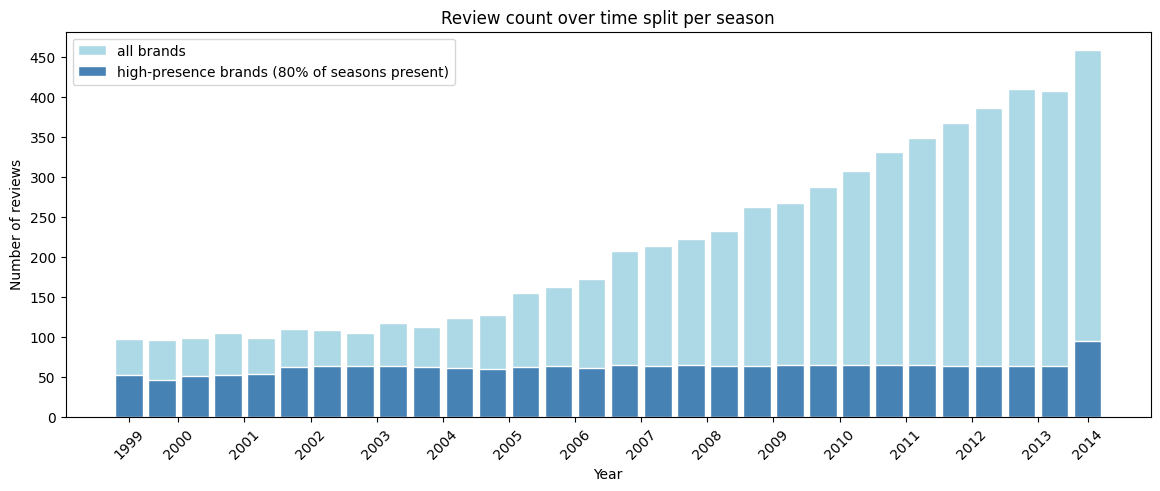

In [ ]:

MIN_SLOTS = 24
df['slot'] = df['year'].astype(str) + '-' + df['season']
slots_per_brand = df.groupby('designer')['slot'].nunique()
high_presence = slots_per_brand[slots_per_brand >= MIN_SLOTS].index

season_rank = {'Fall': 0, 'Spring': 1}
per_slot = df.groupby(['year', 'season']).size()
hp_slot = df[df['designer'].isin(high_presence)].groupby(['year', 'season']).size()

order = sorted(per_slot.index, key=lambda ys: (ys[0], season_rank[ys[1]]))
totals = [per_slot.get(s, 0) for s in order]
hp = [hp_slot.get(s, 0) for s in order]
step = 0.6
pos = [i * step for i in range(len(order))]
width = 0.5
year_pos = {}
for p, (y, seas) in zip(pos, order):
    year_pos.setdefault(y, []).append(p)
tick_pos = [sum(ps) / len(ps) for ps in year_pos.values()]
tick_lab = list(year_pos.keys())

plt.figure(figsize=(14, 5))
plt.bar(pos, totals, width, color='lightblue', edgecolor='white', label='all brands')
plt.bar(pos, hp, width, color='steelblue', edgecolor='white',
        label='high-presence brands (80% of seasons present)')
plt.xlabel('Year')
plt.ylabel('Number of reviews')
plt.title('Review count over time split per season')
plt.xticks(tick_pos, tick_lab, rotation=45)
plt.yticks(range(0, max(totals) + 1, 50))
plt.legend()
plt.show()

## 2. Authors

How many authors are there, and how many reviews did the busiest ones write?

Note: there are 12 reviews with a blank author, so those are not counted here.

In [26]:
# how many blank authors?
print('blank authors:', df['author'].isna().sum())

# count reviews per author (blanks are dropped automatically)
author_counts = df['author'].value_counts()
print('number of authors:', len(author_counts))

print('\ntop 5 authors:')
print(author_counts.head(5))

blank authors: 12
number of authors: 37

top 5 authors:
author
Nicole Phelps    1528
Sarah Mower      1013
Tim Blanks        589
Meenal Mistry     503
Maya Singer       489
Name: count, dtype: int64


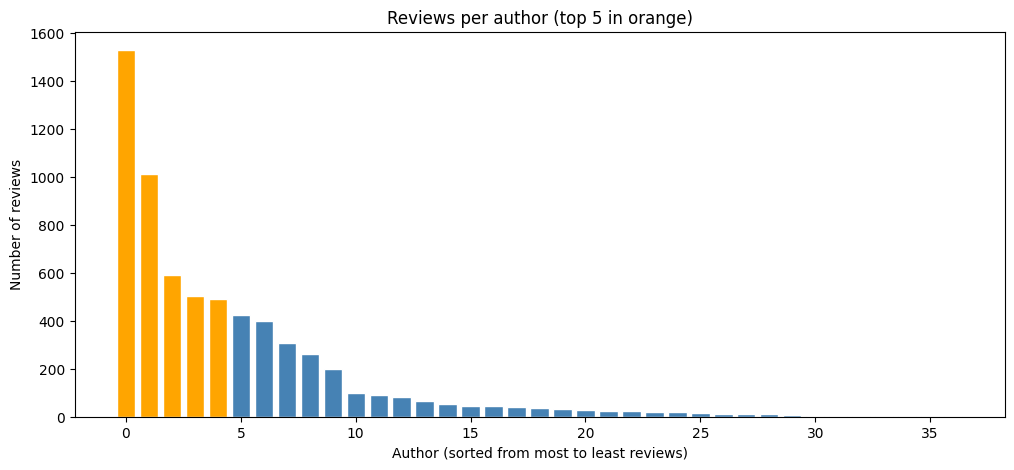

In [27]:
# bar chart of how many reviews each author wrote, top 5 highlighted in orange
colors = ['orange' if i < 5 else 'steelblue' for i in range(len(author_counts))]

plt.figure(figsize=(12, 5))
plt.bar(range(len(author_counts)), author_counts.values, color=colors, edgecolor='white')
plt.xlabel('Author (sorted from most to least reviews)')
plt.ylabel('Number of reviews')
plt.title('Reviews per author (top 5 in orange)')
plt.show()

## 3. Brands

Here we look at how many reviews each brand (designer) has. The histogram shows the distribution: most brands only have a few reviews, and a couple have a lot.

number of brands: 709


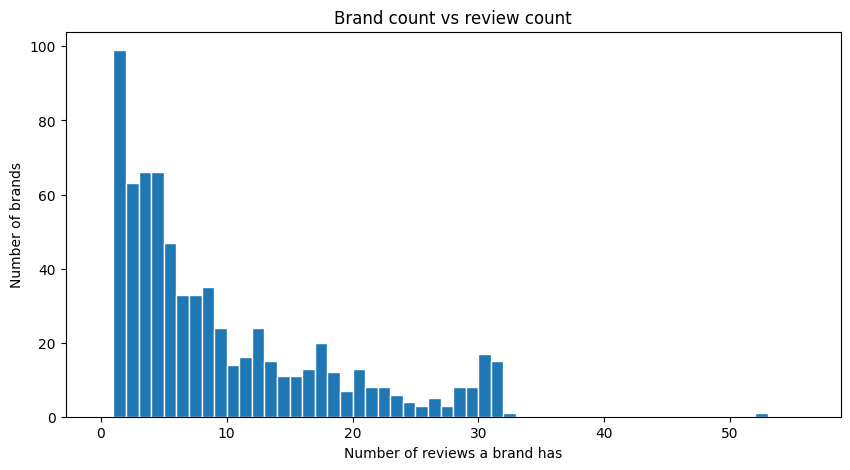

In [28]:
# count reviews per brand
brand_counts = df['designer'].value_counts()
print('number of brands:', len(brand_counts))

plt.figure(figsize=(10, 5))
plt.hist(brand_counts.values, bins=range(0, brand_counts.max() + 5, 1), edgecolor='white')
plt.xlabel('Number of reviews a brand has')
plt.ylabel('Number of brands')
plt.title('Brand count vs review count')
plt.show()

### Investigating outlier

In [6]:
# which brands have more than 50 reviews?
outlier = brand_counts[brand_counts > 50]
print('brands with more than 50 reviews:')
print(outlier)

# look at that brand's reviews over the years
brand_name = outlier.index[0]
print('\nreviews per year for', brand_name, ':')
print(df[df['designer'] == brand_name]['year'].value_counts().sort_index())

brands with more than 50 reviews:
designer
Dolce & Gabbana    52
Name: count, dtype: int64

reviews per year for Dolce & Gabbana :
year
2000    2
2001    4
2002    4
2003    4
2004    4
2005    4
2006    4
2007    2
2008    4
2009    4
2010    4
2011    4
2012    3
2013    2
2014    3
Name: count, dtype: int64


outlier is not dropped as reviews are men/women, still informative for the corpus.

## 4. Which brands and authors have enough data?

In [ ]:
# minimum reviews for a brand/author to count as having enough data.
MIN_REVIEWS = 24 #80% of slots filled

def sweep(counts, universe, label):
    print(f"{label}: how many clear each cutoff, and the share of reviews they cover")
    print(f"{'>= reviews':>10} | {'kept':>5} | {'reviews':>7} | {'% of ' + label:>13}")
    denom = universe.notna().sum()
    for n in [3, 5, 8, 10, 15, 20, 25, 30]:
        kept = counts[counts >= n]
        rev = universe.isin(kept.index).sum()
        mark = '  <- MIN_REVIEWS' if n == MIN_REVIEWS else ''
        print(f"{n:>10} | {len(kept):>5} | {rev:>7} | {rev / denom:>12.1%}{mark}")
    print()

sweep(brand_counts,  df['designer'], 'brands')
sweep(author_counts, df['author'],   'authors')

brands: how many clear each cutoff, and the share of reviews they cover
>= reviews |  kept | reviews |   % of brands
         3 |   547 |    6276 |        96.5%
         5 |   415 |    5814 |        89.4%
         8 |   302 |    5150 |        79.2%
        10 |   243 |    4654 |        71.6%
        15 |   163 |    3701 |        56.9%
        20 |   100 |    2639 |        40.6%
        25 |    61 |    1801 |        27.7%
        30 |    34 |    1059 |        16.3%

authors: how many clear each cutoff, and the share of reviews they cover
>= reviews |  kept | reviews |  % of authors
         3 |    33 |    6484 |        99.9%
         5 |    32 |    6481 |        99.9%
         8 |    30 |    6471 |        99.7%
        10 |    29 |    6463 |        99.6%
        15 |    26 |    6425 |        99.0%
        20 |    23 |    6374 |        98.2%
        25 |    21 |    6328 |        97.5%
        30 |    20 |    6302 |        97.1%



In [62]:
# the brands/authors that clear MIN_REVIEWS - the definition 4.2 and 5.6 rely on
KEPT_BRANDS  = sorted(brand_counts[brand_counts  >= MIN_REVIEWS].index)
KEPT_AUTHORS = sorted(author_counts[author_counts >= MIN_REVIEWS].index)

print(f"MIN_REVIEWS = {MIN_REVIEWS}   <- set this in 4.2 and 5.6")
print(f"  brands kept : {len(KEPT_BRANDS):3} of {len(brand_counts)} "
      f"({df['designer'].isin(KEPT_BRANDS).sum() / len(df):.1%} of reviews)")
print(f"  authors kept: {len(KEPT_AUTHORS):3} of {len(author_counts)} "
      f"({df['author'].isin(KEPT_AUTHORS).sum() / df['author'].notna().sum():.1%} of authored reviews)")
print()

for b in KEPT_BRANDS: print(f"    {b!r},")

MIN_REVIEWS = 24   <- set this in 4.2 and 5.6
  brands kept :  65 of 709 (29.2% of reviews)
  authors kept:  21 of 37 (97.5% of authored reviews)

    'A.F. Vandevorst',
    'Alberta Ferretti',
    'Alexander McQueen',
    'Ann Demeulemeester',
    'Anna Sui',
    'BCBG Max Azria',
    'Badgley Mischka',
    'Balenciaga',
    'Betsey Johnson',
    'Bottega Veneta',
    'Burberry Prorsum',
    'Calvin Klein Collection',
    'Carolina Herrera',
    'Chalayan',
    'Chloé',
    'Christian Dior',
    'Comme des Garçons',
    'Costume National',
    'Céline',
    'DKNY',
    'Diane von Furstenberg',
    'Dolce & Gabbana',
    'Donna Karan',
    'Dries Van Noten',
    'Emilio Pucci',
    'Emporio Armani',
    'Fendi',
    'Gianfranco Ferré',
    'Giorgio Armani',
    'Givenchy',
    'Gucci',
    'Jean Paul Gaultier',
    'Jil Sander',
    'Jill Stuart',
    'John Galliano',
    'Junya Watanabe',
    'Lanvin',
    'Louis Vuitton',
    'Marc Jacobs',
    'Marc by Marc Jacobs',
    'Marni',
   